In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils import (
    PendulumsData,
    ResonanceFitData,
    add_resonance_plot_labels,
    plot_all,
    plot_each,
    save_plot,
)

In [ ]:
data = pd.read_csv("../data/session-4/from5toEnd.csv")
data["t"] += 300
data = data.dropna()

pendulum_data = PendulumsData(
    cols=["mass A", "mass B", "mass C", "mass D"],
    labels=["97cm", "99cm", "99.5cm", "100cm"],
    lengths=np.array([0.97, 0.99, 0.995, 1.0]),
    data=data,
)
pendulum_data.preprocess_offsets()
pendulum_data.normalize()

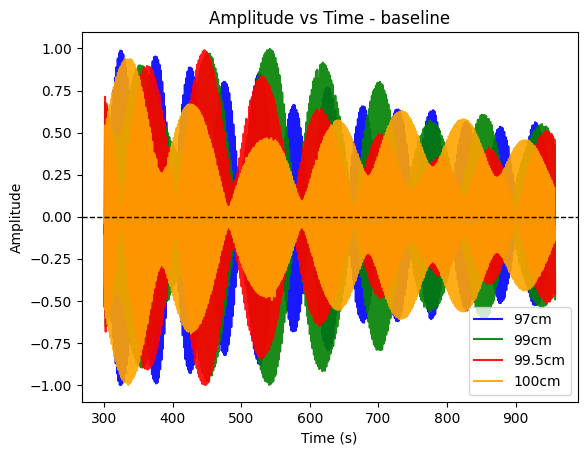

In [3]:
plot_all(pendulum_data, title="Amplitude vs Time - baseline")
save_plot("session-4/amp-vs-time-baseline-all.pdf")
plt.show()

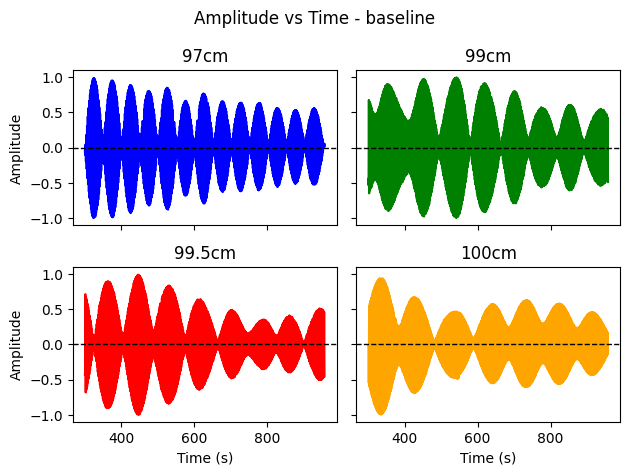

In [4]:
plot_each(pendulum_data, title="Amplitude vs Time - baseline")
save_plot("session-4/amp-vs-time-baseline-each.pdf")
plt.show()

In [5]:
resonance_data = ResonanceFitData(1.0, pendulum_data)

In [6]:
resonance_data.fit()
gamma, err = resonance_data.gamma, resonance_data.gamma_err

print(resonance_data.envelope_data)
print(f"Gamma: {gamma:.4f} ± {err:.4f}")

97cm: peaks=26; mean=0.733
99cm: peaks=14; mean=0.823
99.5cm: peaks=14; mean=0.661
100cm: peaks=14; mean=0.618
Gamma: 0.2718 ± 0.5434


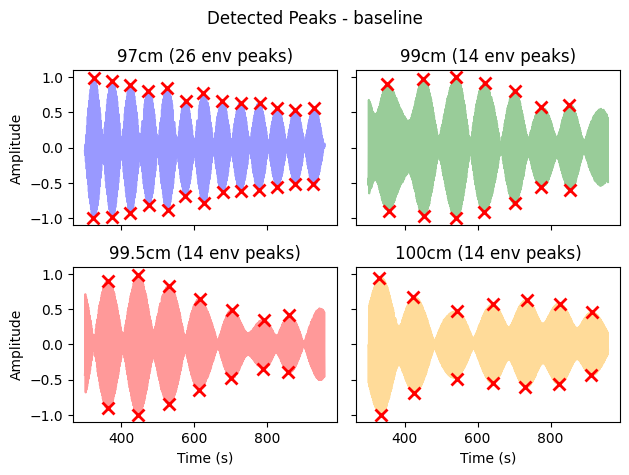

In [7]:
resonance_data.plot_detected_peaks(title="Detected Peaks - baseline")
save_plot("session-4/detected-peaks-baseline.pdf")
plt.show()

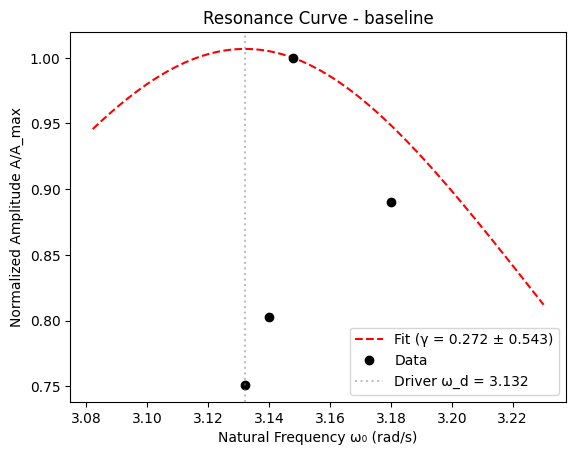

In [8]:
resonance_data.plot_resonance_curve("black", "red")

add_resonance_plot_labels(title="Resonance Curve - baseline")
save_plot("session-4/resonance-curve-baseline.pdf")
plt.show()